# Libraries

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import psycopg2
from sqlalchemy import create_engine
import warnings
from datetime import datetime, timedelta

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
warnings.filterwarnings('ignore')

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


# Load Data

In [2]:
iar_sample_data = pd.read_csv('./iar_20250701_sample.csv')

In [3]:
len(iar_sample_data)

4599813

# Summary Stats

## Unique Count

In [4]:
cols = iar_sample_data.columns
for col in cols:
    ncount = iar_sample_data[col].nunique()
    print(f"{col}: {ncount} ")

data_date: 1 
trans_id: 4599813 
trans_initiate_time: 85453 
customer_msisdn: 1501809 
trx_channel: 2 
trx_type: 7 
trx_status: 1 
ac_from: 2416637 
ac_to: 1103787 
start_balance: 1731638 
trx_amt: 49361 
end_balance: 1636372 
utility_company: 141 
bill_ref_number: 377817 
fee: 8417 
fed: 3152 
reason_type: 211 
pur_of_remit: 1 
ec: 0 
merchant_id: 0 


## Null Count

In [17]:
cols = iar_sample_data.columns
for col in cols:
    null_count = iar_sample_data[col].isnull().sum()
    print(f"{col}: {null_count} ")

data_date: 0 
trans_id: 0 
trans_initiate_time: 0 
customer_msisdn: 24283 
trx_channel: 0 
trx_type: 0 
trx_status: 0 
ac_from: 1100 
ac_to: 516563 
start_balance: 0 
trx_amt: 0 
end_balance: 0 
utility_company: 3787491 
bill_ref_number: 4194914 
fee: 0 
fed: 0 
reason_type: 0 
pur_of_remit: 4184984 
ec: 4599813 
merchant_id: 4599813 


## Amount Distribution

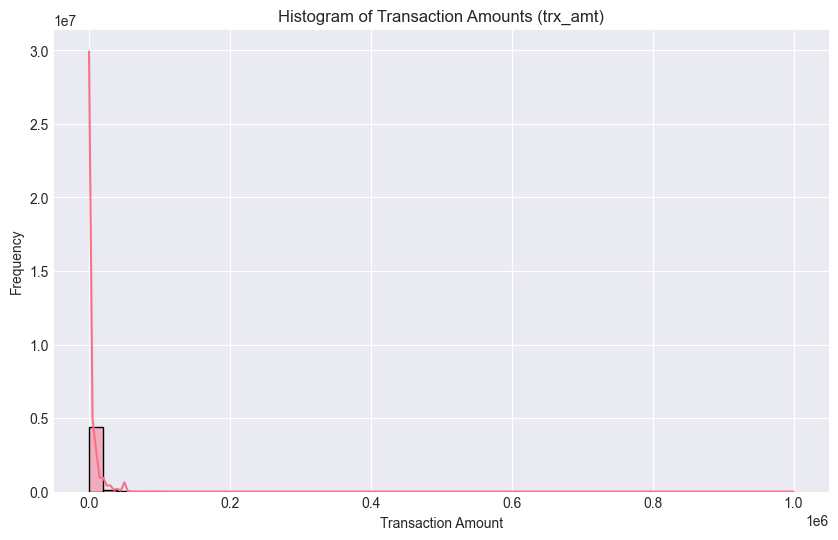

In [5]:
plt.figure(figsize=(10, 6))
sns.histplot(iar_sample_data['trx_amt'], bins=50, kde=True)
plt.title('Histogram of Transaction Amounts (trx_amt)')
plt.xlabel('Transaction Amount')
plt.ylabel('Frequency')
plt.show()

# Amount Outliers

In [ ]:
from scipy.stats import zscore
z_scores = zscore(iar_sample_data['trx_amt'])
outliers_z = iar_sample_data[np.abs(z_scores) > 3]
print(f"Z-Score Outliers: {len(outliers_z)}")

Z-Score Outliers: 99932


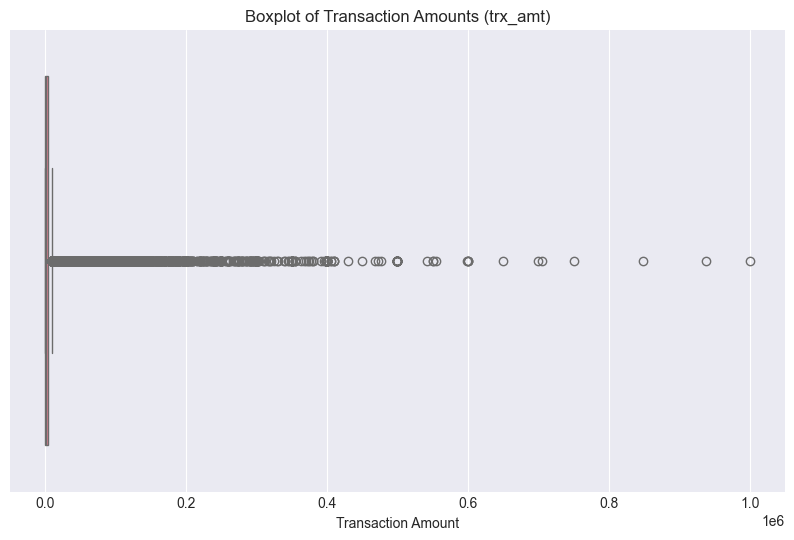

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=iar_sample_data['trx_amt'])
plt.title('Boxplot of Transaction Amounts (trx_amt)')
plt.xlabel('Transaction Amount')
plt.show()

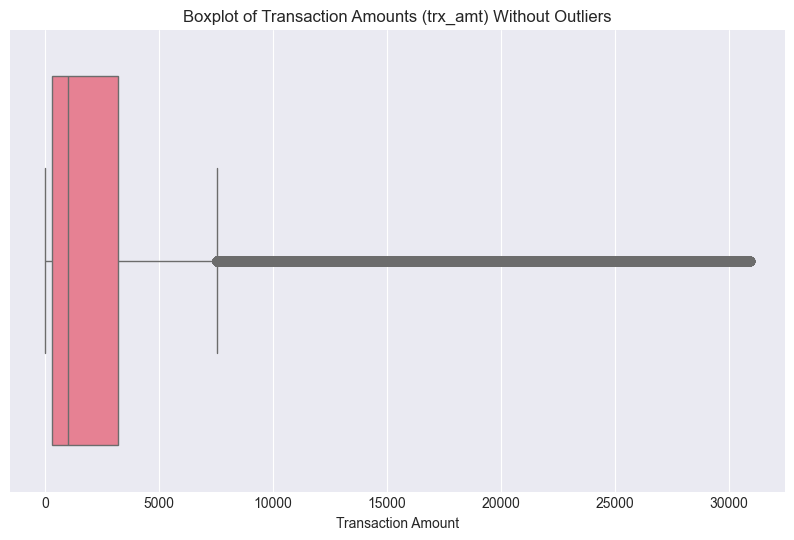

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=iar_sample_data.loc[~iar_sample_data.index.isin(outliers_std.index), 'trx_amt'])
plt.title('Boxplot of Transaction Amounts (trx_amt) Without Outliers')
plt.xlabel('Transaction Amount')
plt.show()

In [5]:

# Cluster based only on 'trx_amt'
from sklearn.cluster import KMeans
from sklearn.discriminant_analysis import StandardScaler
from sklearn.metrics import silhouette_score


amt_values = iar_sample_data[['trx_amt']].fillna(0)

scaler_amt = StandardScaler()
amt_scaled = scaler_amt.fit_transform(amt_values)

# # Find optimal number of clusters using silhouette score
# scores_amt = []
# K_range = range(5, 10)
# for k in K_range:
kmeans_amt = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_amt = kmeans_amt.fit_predict(amt_scaled)
#     score_amt = silhouette_score(amt_scaled, labels_amt)
#     scores_amt.append(score_amt)

# best_k_amt = K_range[scores_amt.index(max(scores_amt))]
# print(f"Best number of clusters (amt only): {best_k_amt}")

# # Fit KMeans with best_k_amt
# kmeans_amt = KMeans(n_clusters=best_k_amt, random_state=42, n_init=10)
# iar_sample_data['cluster_amt'] = kmeans_amt.fit_predict(amt_scaled)


NameError: name 'k' is not defined